In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [37]:
import pandas as pd

train= pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
train.shape
train.head

<bound method NDFrame.head of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       pi

In [38]:
test= pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")
test.head


<bound method NDFrame.head of        pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
27995       0       0       0       0       0       0       0       0       0   
27996       0       0       0       0       0       0       0       0       0   
27997       0       0       0       0       0       0       0       0       0   
27998       0       0       0       0       0       0       0       0       0   
27999       0       0       0       0       0       0       0       0       0  

In [39]:
y = train['label']
X = train.drop('label', axis=1)
X = X / 255.0
test = test / 255.0
print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [40]:
from sklearn.linear_model import LogisticRegression

model= LogisticRegression(max_iter=1000)
model.fit(X,y)
predictions = model.predict(test)


In [41]:
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions)+1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [42]:
import os
print(os.listdir())

['.virtual_documents', 'submission.csv']


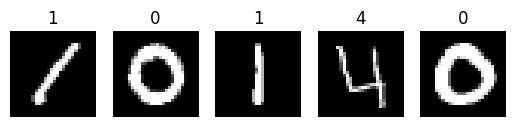

In [43]:
import matplotlib.pyplot as plt

for i in range(5):
    image = X.iloc[i].values.reshape(28, 28)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(y.iloc[i])
    plt.axis('off')

plt.show()

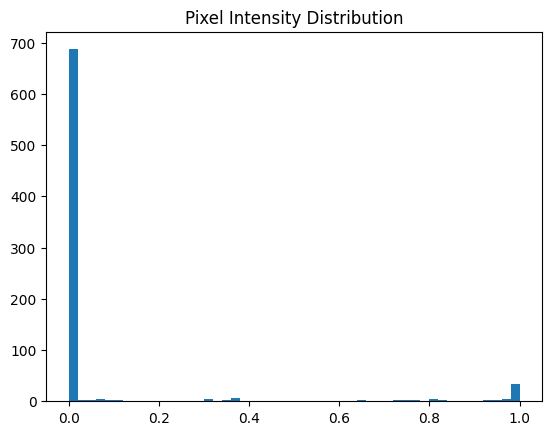

In [44]:
import matplotlib.pyplot as plt

plt.hist(X.iloc[0], bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

In [45]:
# fresh data for CNN
y = train['label']
X = train.drop('label', axis=1)

X = X / 255.0
test_scaled = test / 255.0

In [46]:
import numpy as np

X = np.array(X).reshape(-1, 28, 28, 1)
test_scaled = np.array(test_scaled).reshape(-1, 28, 28, 1)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))   # NEW layer
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [52]:
model.fit(X, y, epochs=5)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9931 - loss: 0.0234
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9948 - loss: 0.0156
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9958 - loss: 0.0123
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9965 - loss: 0.0096
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9974 - loss: 0.0077


In [53]:
predictions = model.predict(test_scaled)

875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


In [54]:
import numpy as np

predictions = np.argmax(predictions, axis=1)
print(predictions[:10])

[1 1 1 1 1 1 1 1 1 1]


In [55]:
print(y[:10])

0    1
1    0
2    1
3    4
4    0
5    0
6    7
7    3
8    5
9    3
Name: label, dtype: int64


In [56]:
print(X.shape)
print(test_scaled.shape)

(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [57]:
print(X[0])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 

In [58]:
y = train['label']
X = train.drop('label', axis=1)

print(X.iloc[0][:10])   # check raw values

pixel0    0
pixel1    0
pixel2    0
pixel3    0
pixel4    0
pixel5    0
pixel6    0
pixel7    0
pixel8    0
pixel9    0
Name: 0, dtype: int64


In [59]:
X = X / 255.0
test_scaled = test / 255.0

print(X.iloc[0][:10])

pixel0    0.0
pixel1    0.0
pixel2    0.0
pixel3    0.0
pixel4    0.0
pixel5    0.0
pixel6    0.0
pixel7    0.0
pixel8    0.0
pixel9    0.0
Name: 0, dtype: float64


In [60]:

print(X.iloc[0].sum())


65.29019607843136


In [61]:
import numpy as np

X = np.array(X).reshape(-1, 28, 28, 1)
test_scaled = np.array(test_scaled).reshape(-1, 28, 28, 1)

print(X.shape)

(42000, 28, 28, 1)


In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.8885 - loss: 0.3608
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9843 - loss: 0.0498
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9903 - loss: 0.0328
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9935 - loss: 0.0209
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9956 - loss: 0.0148


In [63]:
predictions = model.predict(test_scaled)


875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


In [64]:
import numpy as np

predictions = np.argmax(predictions, axis=1)
print(predictions[:10])

[1 1 1 1 1 1 1 1 1 1]


In [65]:
print(test_scaled.shape)
print(test_scaled[0].sum())

(28000, 28, 28, 1)
0.6059823144944253


In [66]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [67]:
pred_train = model.predict(X)
pred_train = np.argmax(pred_train, axis=1)

print(pred_train[:10])
print(y[:10].values)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
[1 0 1 4 0 0 7 3 5 3]
[1 0 1 4 0 0 7 3 5 3]


In [69]:
# rebuild test clean (from original test)
test_scaled = test.copy()

test_scaled = test_scaled / 255.0
test_scaled = test_scaled.values.reshape(-1, 28, 28, 1)

In [71]:
predictions = model.predict(test_scaled)
predictions = np.argmax(predictions, axis=1)

print(predictions[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
[1 1 1 1 1 1 1 1 1 1]


In [72]:
test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')
test_scaled = test / 255.0
test_scaled = test_scaled.values.reshape(-1, 28, 28, 1)
predictions = model.predict(test_scaled)
predictions = np.argmax(predictions, axis=1)

print(predictions[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
[2 0 9 9 3 7 0 3 0 3]


In [73]:
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions)+1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)